# **House Price Prediction (Regression)**

# **Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.

Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

# **Objective**
The objective of this task is to:

● Understand and explore the housing dataset.

● Perform data preprocessing including handling missing values, duplicates, and outliers.

● Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the data.

● Apply encoding, log transformation, and feature scaling where necessary.

● Train multiple regression algorithms to predict house prices.

● Evaluate and compare model performance using appropriate evaluation metrics.

#**Tasks**

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load the Dataset

In [2]:
df = pd.read_csv("house_price_regression_dataset.csv")

# 3. Check Dataset

In [3]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


# 4. Handle Missing Values

In [4]:
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


# 5. Remove Duplicate Records

In [5]:
df.duplicated().sum()

df.drop_duplicates(inplace=True)

# 6. Perform Univariate Analysis

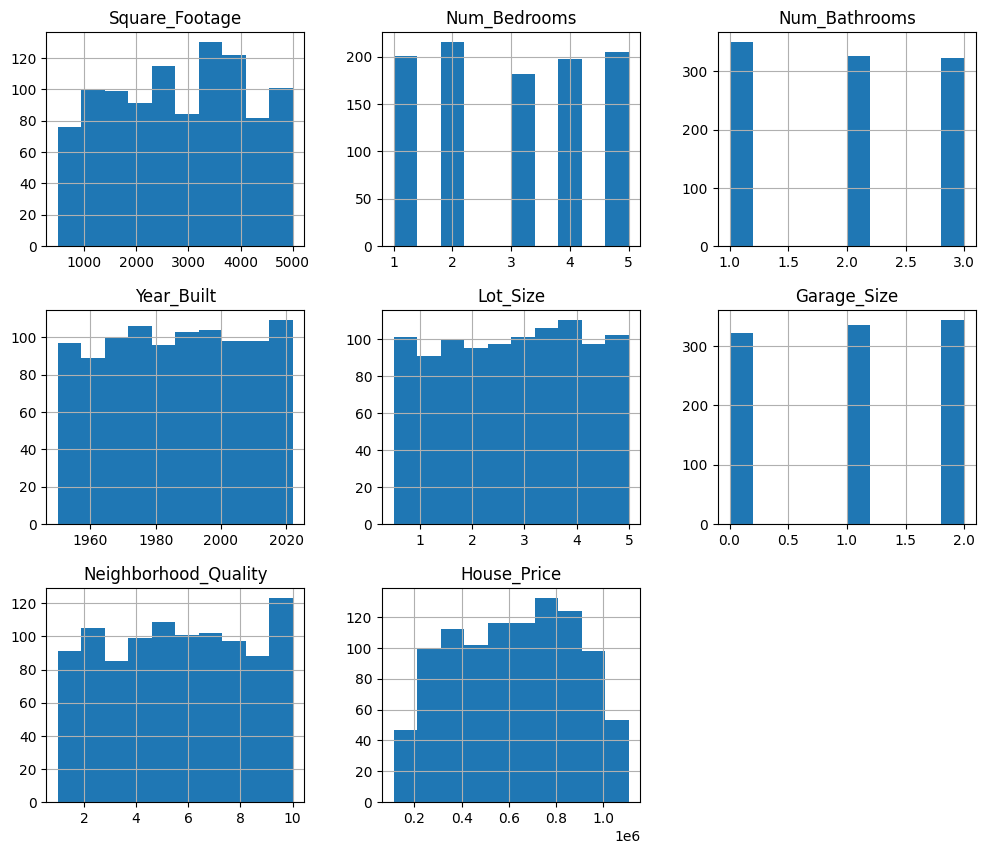

In [6]:
df.hist(figsize=(12,10))
plt.show()

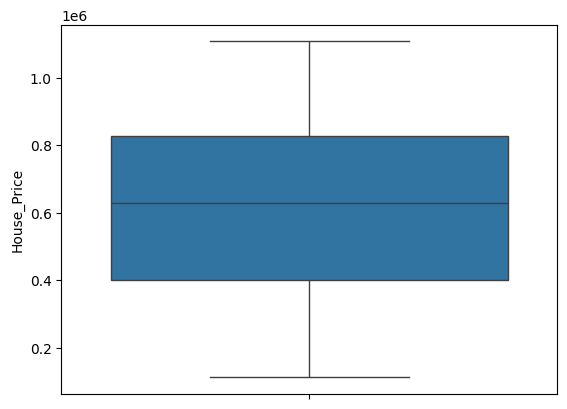

In [7]:
sns.boxplot(df['House_Price'])
plt.show()

# 7. Perform Bivariate Analysis

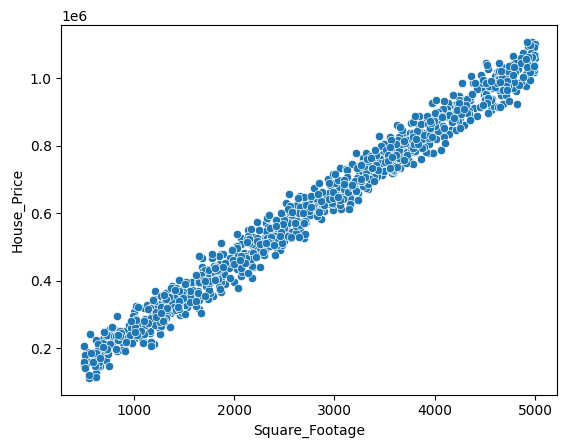

In [8]:
sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.show()

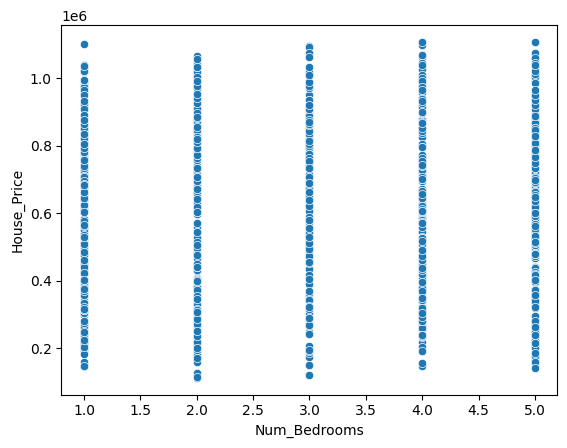

In [9]:
sns.scatterplot(x='Num_Bedrooms', y='House_Price', data=df)
plt.show()

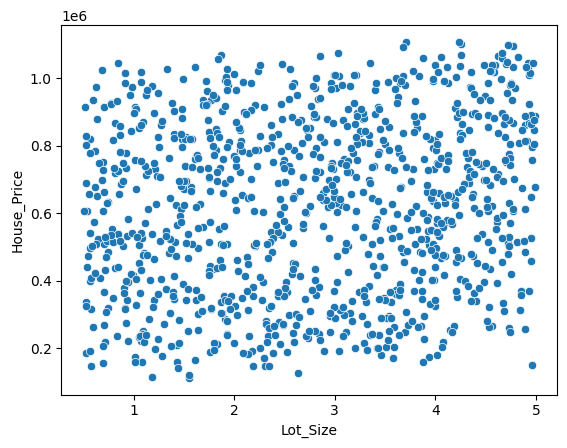

In [10]:
sns.scatterplot(x='Lot_Size', y='House_Price', data=df)
plt.show()

# 8. Generate Correlation Heatmap

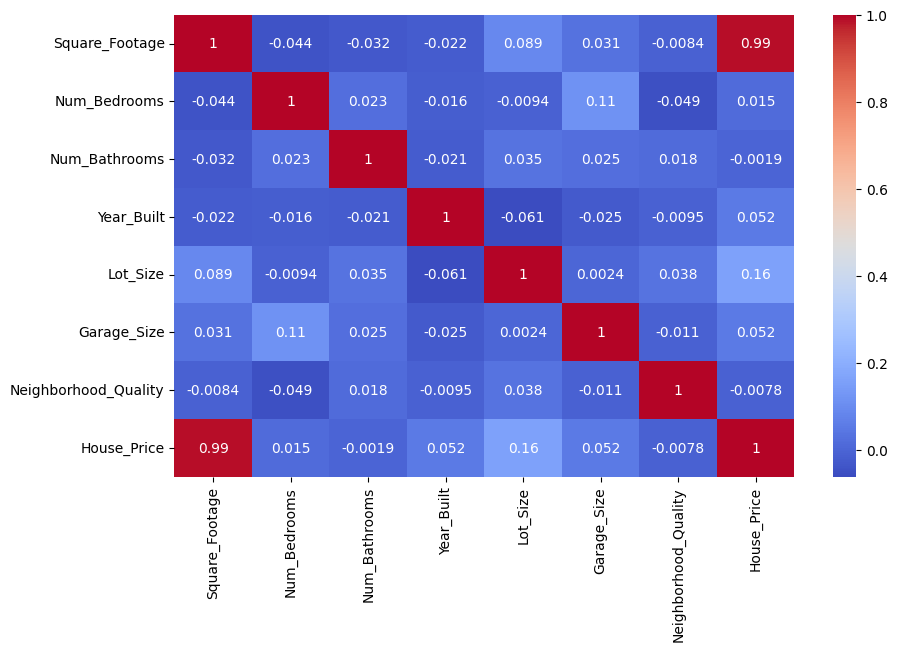

In [11]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

# 9. Detect and Handle Outliers

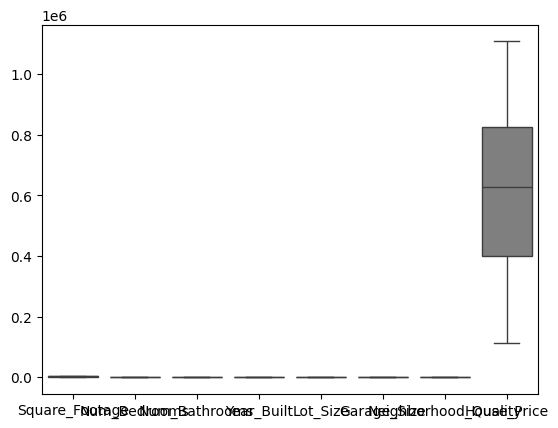

In [12]:
sns.boxplot(data=df)
plt.show()

In [13]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)]

# 10. Apply Encoding (if categorical variables exist)

Not required because all variable are numeric.

# 11. Apply Log Transformation

In [14]:
df['House_Price'] = np.log(df['House_Price'])

# 12. Separate Features and Target Variable

In [15]:
X = df.drop('House_Price', axis=1)

y = df['House_Price']

# 13. Perform Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

# 14. Apply Feature Scaling

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 15. Train Regression Models
● Linear Regression
● KNN regression

**Linear Regression**

In [18]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

**KNN Regression**

In [19]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

# 16. Evaluate Models Using
● MAE (Mean Absolute Error)

● MSE (Mean Squared Error)

● RMSE (Root Mean Squared Error)

● MAPE

● R² Score

● Adjusted r2

In [20]:
def evaluate_model(y_test, y_pred, n, p):

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    r2 = r2_score(y_test, y_pred)

    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAPE:", mape)
    print("R2:", r2)
    print("Adjusted R2:", adj_r2)

**Evaluate Linear Regression**

In [21]:
evaluate_model(y_test, y_pred_lr, X_test.shape[0], X_test.shape[1])

MAE: 0.09078292767761202
MSE: 0.012923132230239545
RMSE: 0.11367995527022143
MAPE: 0.695987033882357
R2: 0.9462493474741257
Adjusted R2: 0.9442896882674532


**Evaluate KNN**

In [22]:
evaluate_model(y_test, y_pred_knn, X_test.shape[0], X_test.shape[1])

MAE: 0.13352458657348393
MSE: 0.03275242370493434
RMSE: 0.18097630702645676
MAPE: 1.0316078365784032
R2: 0.8637741907627683
Adjusted R2: 0.8588076248009943
